# Task 4

### Importing libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as functional
from torch.distributions import Normal, kl_divergence
from torch.utils.data import DataLoader
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt 

if torch.cuda.is_available() == True:
    device = 'cuda'
else:
    device = 'cpu'

print(f'device: {device}')



device: cpu


# Task 4.1

### Loading dataset

In [2]:
mnist_train = datasets.MNIST(root='../data', train=True, transform=transforms.ToTensor(), download=True)
mnist_test = datasets.MNIST(root='../data', train=False, transform=transforms.ToTensor(), download=True)

train_dataloader = DataLoader(mnist_train, batch_size=64, shuffle=True)
test_dataloader = DataLoader(mnist_test, batch_size=64, shuffle=False)



### Implementing VAE from scratch

In [3]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        self.mean_layer = nn.Linear(128, 32)
        self.logvar_layer = nn.Linear(128, 32)

        self.normal_distribution = Normal(0, 1)

        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x_encoded = self.encoder(x)

        x_mean = self.mean_layer(x_encoded)
        x_logvar = self.logvar_layer(x_encoded)

        x_dev = torch.exp(0.5 * x_logvar)
        normal_sampled = self.normal_distribution.sample((x_mean.shape[0], x_mean.shape[1]))

        z = x_mean + x_dev * normal_sampled

        x_decoded = self.decoder(z)

        return x_decoded, x_mean, x_logvar

    def compute_loss(self, x, x_mean, x_logvar, output):
        distribution_1 = Normal(x_mean, torch.exp(0.5 * x_logvar))
        distribution_2 = self.normal_distribution

        loss = kl_divergence(distribution_1, distribution_2).sum(dim=1) + functional.binary_cross_entropy(output, x, reduction='none').sum(dim=1)

        return loss.sum(dim=0)/loss.shape[0]




### Training the VAE

In [4]:
vae = VAE()
EPOCHS = 15
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

loss_over_epochs = []

for i in range(EPOCHS):
    print(f'epoch: {i}')
    curr_loss = 0

    vae.train()
    
    for image, label in train_dataloader:
        optimizer.zero_grad()

        image = torch.flatten(image, start_dim=1)

        output, image_mean, image_logvar = vae(image)

        loss = vae.compute_loss(image, image_mean, image_logvar, output)
        curr_loss += loss.item()

        loss.backward()

        optimizer.step()

    curr_loss = curr_loss / len(train_dataloader)
    loss_over_epochs.append(curr_loss)
    print(f'loss: {curr_loss} \n')



epoch: 0
loss: 171.7645004451402 

epoch: 1
loss: 130.07281106163953 

epoch: 2
loss: 122.63672261349936 

epoch: 3
loss: 119.21202111803392 

epoch: 4
loss: 116.94432958509368 

epoch: 5
loss: 115.38431653996774 

epoch: 6
loss: 114.12166054569073 

epoch: 7
loss: 113.20605621663238 

epoch: 8
loss: 112.40182007909584 

epoch: 9
loss: 111.71202650253198 

epoch: 10
loss: 111.17384488038671 

epoch: 11
loss: 110.72447390037813 

epoch: 12
loss: 110.32986982138172 

epoch: 13
loss: 109.90837960151721 

epoch: 14
loss: 109.5416825707279 



### Visualizing loss

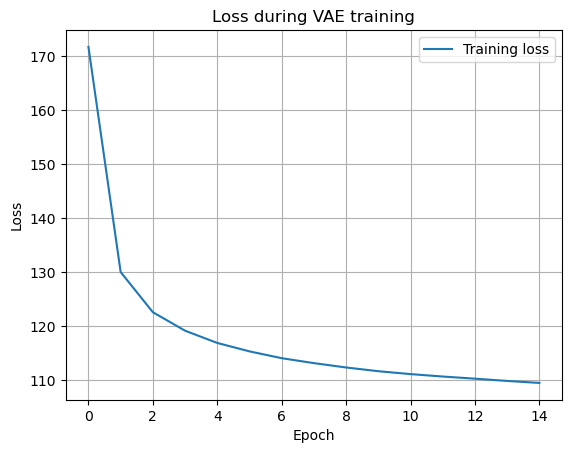

In [5]:
plt.figure()
plt.plot(loss_over_epochs, label='Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss during VAE training')
plt.grid()
plt.legend()

plt.show()